In [1]:
import os
import random
import shutil
import zipfile
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Chest XRays - RadioGraphy

In [2]:
base_dir = "/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset"

categories = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

for category in categories:
    image_dir = os.path.join(base_dir, category, "images")
    if os.path.exists(image_dir):
        num_images = len([
            f for f in os.listdir(image_dir)
            if os.path.isfile(os.path.join(image_dir, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])
        print(f"{category}: {num_images} images")
    else:
        print(f"{category}: Folder not found")

COVID: 3616 images
Lung_Opacity: 6012 images
Normal: 10192 images
Viral Pneumonia: 1345 images


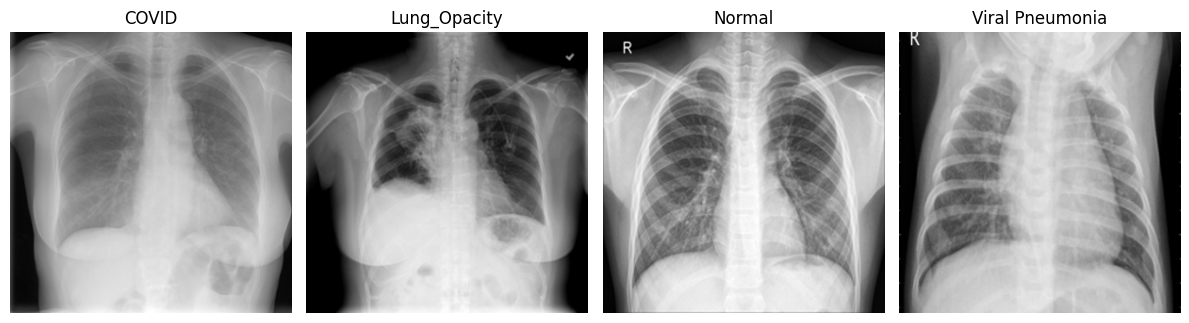

In [3]:
covid19_dir = "/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset"

categories = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

plt.figure(figsize=(12, 4))

for i, category in enumerate(categories):
    image_folder = os.path.join(covid19_dir, category, "images")
    image_files = [f for f in os.listdir(image_folder) if os.path.isfile(os.path.join(image_folder, f))]

    if image_files:
        sample_image_path = os.path.join(image_folder, image_files[0])
        image = Image.open(sample_image_path)

        plt.subplot(1, len(categories), i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(category)
        plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
root_folder = "All_Medical_Images"
images_folder = os.path.join(root_folder, "images")

os.makedirs(images_folder, exist_ok=True)

# Categories and their directories for Chest X-rays
categories = {
    "COVID": os.path.join(base_dir, "COVID", "images"),
    "Lung_Opacity": os.path.join(base_dir, "Lung_Opacity", "images"),
    # "Normal": os.path.join(base_dir, "Normal", "images"),
    "Viral_Pneumonia": os.path.join(base_dir, "Viral Pneumonia", "images")
}

data = []

image_count = {cat: 1 for cat in categories.keys()}
for category, category_dir in categories.items():
    if os.path.exists(category_dir):
        for filename in os.listdir(category_dir):
            if filename.lower().endswith((".png", ".jpg", ".jpeg")):
                src_path = os.path.join(category_dir, filename)
                new_filename = f"chest_{category.replace(' ', '_')}_{image_count[category]}"
                dst_path = os.path.join(images_folder, f"{new_filename}.png")
                shutil.copy(src_path, dst_path)  # Copy instead of move
                data.append({"filename": f"{new_filename}.png", "label": category})
                image_count[category] += 1
    else:
        print(f"{category}: Folder not found")

# Brain MRIs

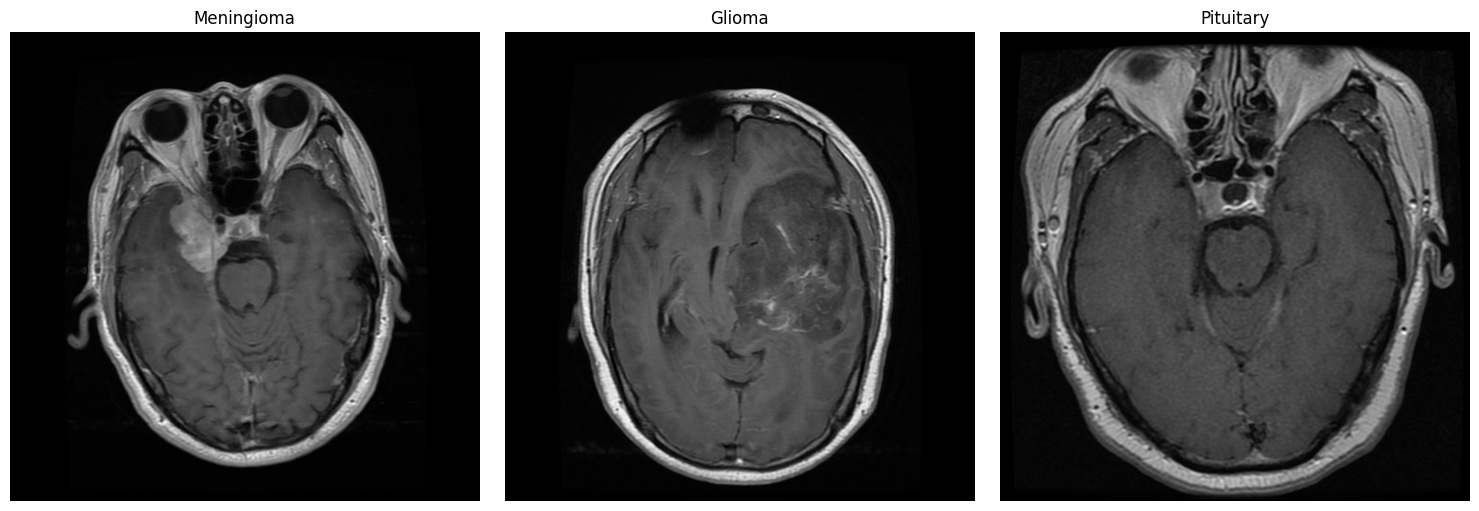

In [5]:
brain_tumor_dir = "/kaggle/input/brain-tumor-dataset/brainTumorDataPublic_1-766"

label_map = {1: "Meningioma", 2: "Glioma", 3: "Pituitary"}

found = {}

mat_files = [f for f in os.listdir(brain_tumor_dir) if f.endswith(".mat")]

for file in mat_files:
    if len(found) == 3:
        break
    file_path = os.path.join(brain_tumor_dir, file)
    with h5py.File(file_path, 'r') as f:
        label = int(f['cjdata']['label'][()][0][0])
        if label not in found:
            image = f['cjdata']['image'][()]
            image = np.array(image).T
            image = (image - np.min(image)) / (np.max(image) - np.min(image))  # normalize
            found[label] = image

plt.figure(figsize=(15, 5))
for i, label in enumerate(sorted(found.keys()), 1):
    plt.subplot(1, 3, i)
    plt.imshow(found[label], cmap='gray')
    plt.title(label_map[label])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
label_map = {1: "Meningioma", 2: "Glioma", 3: "Pituitary"}

mat_dirs = [
    os.path.join("/kaggle/input/brain-tumor-dataset", "brainTumorDataPublic_1-766"),
    os.path.join("/kaggle/input/brain-tumor-dataset", "brainTumorDataPublic_767-1532"),
    os.path.join("/kaggle/input/brain-tumor-dataset", "brainTumorDataPublic_1533-2298"),
    os.path.join("/kaggle/input/brain-tumor-dataset", "brainTumorDataPublic_2299-3064")
]

image_count = {"Meningioma": 1, "Glioma": 1, "Pituitary": 1}
for mat_dir in mat_dirs:
    if os.path.exists(mat_dir):
        mat_files = [f for f in os.listdir(mat_dir) if f.endswith(".mat")]
        for file in mat_files:
            file_path = os.path.join(mat_dir, file)
            with h5py.File(file_path, 'r') as f:
                label = int(f['cjdata']['label'][()][0][0])
                category = label_map[label]
                image = f['cjdata']['image'][()]
                image = np.array(image).T
                image = (image - np.min(image)) / (np.max(image) - np.min(image))  # Normalize
                new_filename = f"brain_{category}_{image_count[category]}"
                image_path = os.path.join(images_folder, f"{new_filename}.png")
                plt.imsave(image_path, image, cmap='gray', format='png')
                data.append({"filename": f"{new_filename}.png", "label": category})
                image_count[category] += 1
    else:
        print(f"Directory {mat_dir} not found")

# Endoscopy - Esophagitis

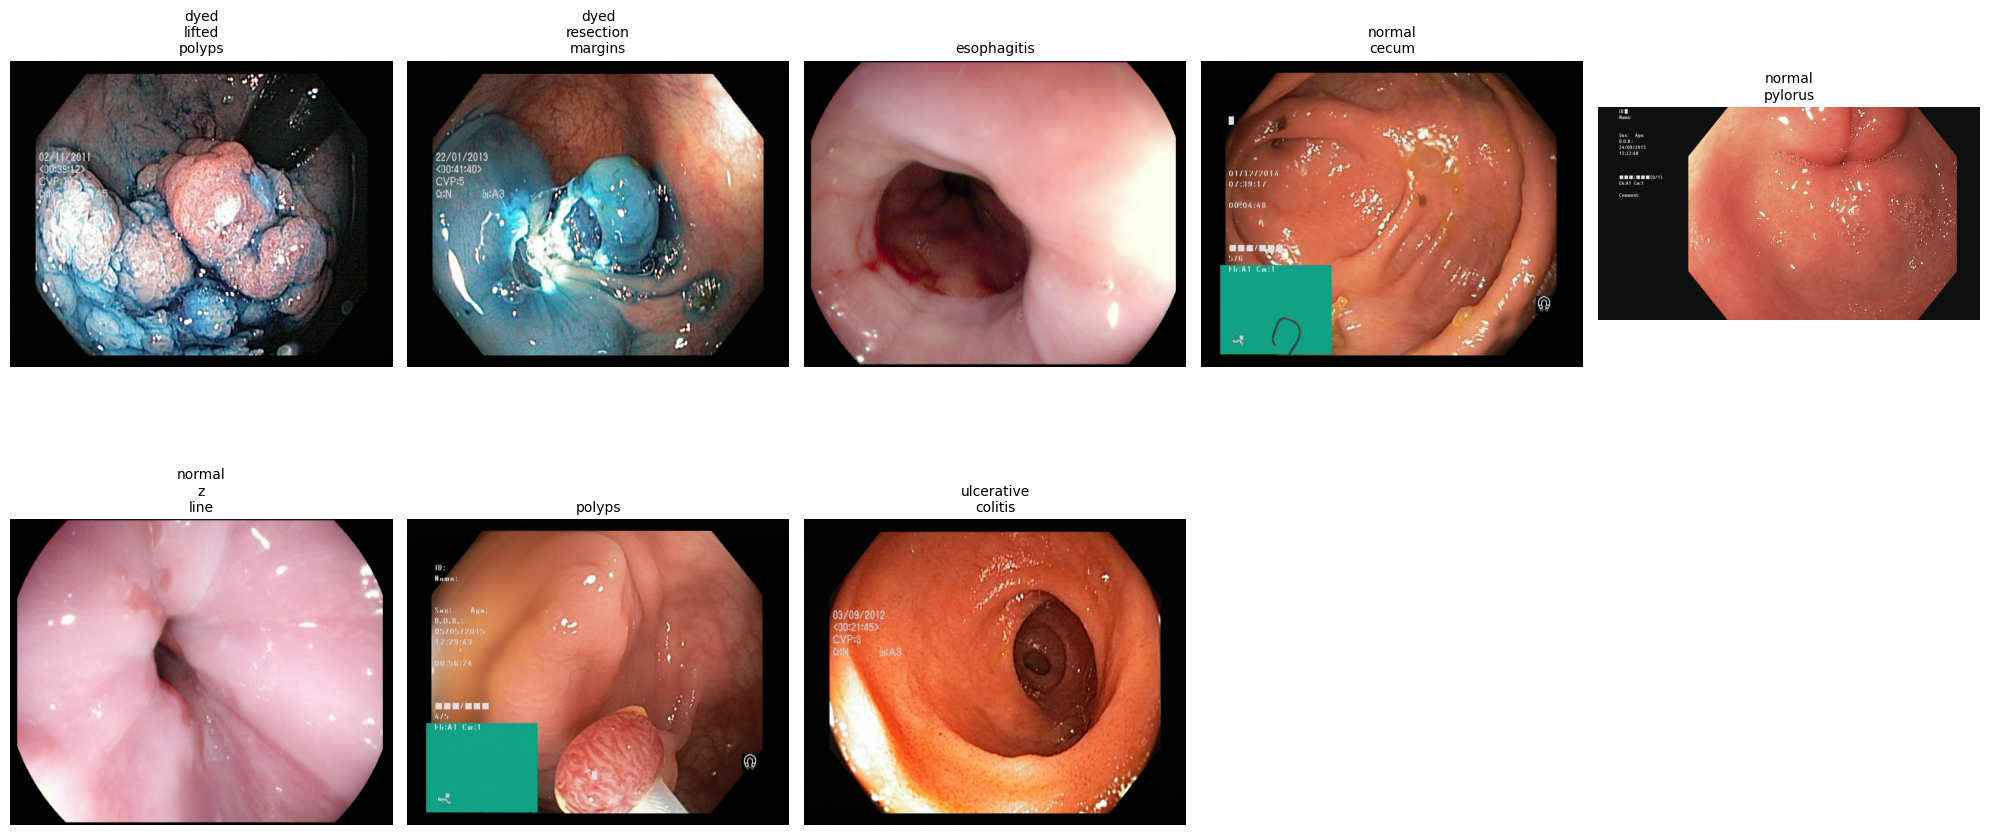

In [7]:
endoscopy_dir = "/kaggle/input/kvasir-endoscopy-dataset/kvasir-dataset" 

categories = ["dyed-lifted-polyps", "dyed-resection-margins", "esophagitis", "normal-cecum", 
              "normal-pylorus", "normal-z-line", "polyps", "ulcerative-colitis"]

plt.figure(figsize=(20, 10))

for i, category in enumerate(categories):
    image_folder = os.path.join(endoscopy_dir, category)
    image_files = [f for f in os.listdir(image_folder) if os.path.isfile(os.path.join(image_folder, f))]
    
    if not image_files:
        continue  

    sample_image_path = os.path.join(image_folder, random.choice(image_files))
    image = Image.open(sample_image_path)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(category.replace('-', '\n'), fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
categories = ["esophagitis", "polyps", "ulcerative-colitis"]

image_count = {"esophagitis": 1, "polyps": 1, "ulcerative-colitis": 1}
for category in categories:
    image_folder = os.path.join(endoscopy_dir, category)
    if os.path.exists(image_folder):
        image_files = [f for f in os.listdir(image_folder) if os.path.isfile(os.path.join(image_folder, f))]
        for filename in image_files:
            src_path = os.path.join(image_folder, filename)
            new_filename = f"endo_{category.replace('-', '_')}_{image_count[category]}"
            dst_path = os.path.join(images_folder, f"{new_filename}.png")
            shutil.copy(src_path, dst_path)  # Copy instead of move due to read-only input
            data.append({"filename": f"{new_filename}.png", "label": category})
            image_count[category] += 1
    else:
        print(f"Directory {image_folder} not found")

csv_path = os.path.join(root_folder, "image_labels.csv")
df = pd.DataFrame(data)
df.to_csv(csv_path, index=False)

# Zip the root folder
zip_path = root_folder + ".zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(root_folder):
        for file in files:
            file_path = os.path.join(root, file)
            zipf.write(file_path, os.path.relpath(file_path, root_folder))

print(f"Created {zip_path} containing the dataset and CSV file.")

Created All_Medical_Images.zip containing the dataset and CSV file.
